# ECG Arrhythmia Classification with 1D-CNN

Trains a **1D Convolutional Neural Network** to classify ECG beats into arrhythmia types using the **MIT-BIH Arrhythmia Database**. Covers data ingestion, preprocessing, model training, evaluation, and Grad-CAM explainability.

| Class | Label | Description |
|-------|-------|-------------|
| N | Normal | Regular SA-node rhythm |
| S | Supraventricular ectopic | Originates above the ventricles |
| V | Ventricular ectopic | Wide QRS, abnormal ventricular focus |
| F | Fusion | Simultaneous normal + ectopic activation |
| Q | Unknown / Paced | Unclassifiable or paced beats |

---

## 0. Imports

In [1]:
# Standard library
import os
from collections import Counter, defaultdict
import itertools

# Numerical
import numpy as np

# Signal processing
import wfdb
from scipy.signal import butter, filtfilt

# Machine learning
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, f1_score

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

# Explainability
import shap as sh
from scipy import stats

## 1. Setup — Folder Structure & Data Download

In [2]:
import shutil
import wfdb

DATA_DIR = "data/raw/mitdb"

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)

os.makedirs(DATA_DIR, exist_ok=True)

print("Downloading MIT-BIH dataset...")
wfdb.dl_database("mitdb", DATA_DIR)
print("Download complete.")

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [3]:
import os

DATA_DIR = "data/raw/mitdb"

files = sorted(os.listdir(DATA_DIR))

print(f"Files currently downloaded: {len(files)}")
print(files)

Files currently downloaded: 144
['100.atr', '100.dat', '100.hea', '101.atr', '101.dat', '101.hea', '102.atr', '102.dat', '102.hea', '103.atr', '103.dat', '103.hea', '104.atr', '104.dat', '104.hea', '105.atr', '105.dat', '105.hea', '106.atr', '106.dat', '106.hea', '107.atr', '107.dat', '107.hea', '108.atr', '108.dat', '108.hea', '109.atr', '109.dat', '109.hea', '111.atr', '111.dat', '111.hea', '112.atr', '112.dat', '112.hea', '113.atr', '113.dat', '113.hea', '114.atr', '114.dat', '114.hea', '115.atr', '115.dat', '115.hea', '116.atr', '116.dat', '116.hea', '117.atr', '117.dat', '117.hea', '118.atr', '118.dat', '118.hea', '119.atr', '119.dat', '119.hea', '121.atr', '121.dat', '121.hea', '122.atr', '122.dat', '122.hea', '123.atr', '123.dat', '123.hea', '124.atr', '124.dat', '124.hea', '200.atr', '200.dat', '200.hea', '201.atr', '201.dat', '201.hea', '202.atr', '202.dat', '202.hea', '203.atr', '203.dat', '203.hea', '205.atr', '205.dat', '205.hea', '207.atr', '207.dat', '207.hea', '208.atr',

In [4]:
records = sorted(
    os.path.splitext(f)[0]
    for f in files
    if f.endswith(".hea")
)

print(f"Header files: {len(records)}")
print(records)

Header files: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [5]:
# 3. Read the signal
rec = wfdb.rdrecord("data/raw/mitdb/100")

# 4. Read the annotations
ann = wfdb.rdann("data/raw/mitdb/100", "atr")

# 5. Inspect both
print(rec.__dict__.keys())
print(ann.__dict__.keys())

dict_keys(['record_name', 'n_sig', 'fs', 'counter_freq', 'base_counter', 'sig_len', 'base_time', 'base_date', 'comments', 'sig_name', 'p_signal', 'd_signal', 'e_p_signal', 'e_d_signal', 'file_name', 'fmt', 'samps_per_frame', 'skew', 'byte_offset', 'adc_gain', 'baseline', 'units', 'adc_res', 'adc_zero', 'init_value', 'checksum', 'block_size'])
dict_keys(['record_name', 'extension', 'sample', 'symbol', 'subtype', 'chan', 'num', 'aux_note', 'fs', 'label_store', 'description', 'custom_labels', 'contained_labels', 'ann_len'])


In [6]:
RECORD_IDS = records
for rec_id in RECORD_IDS:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_id))
    print(rec_id, rec.sig_name)

100 ['MLII', 'V5']
101 ['MLII', 'V1']
102 ['V5', 'V2']
103 ['MLII', 'V2']
104 ['V5', 'V2']
105 ['MLII', 'V1']
106 ['MLII', 'V1']
107 ['MLII', 'V1']
108 ['MLII', 'V1']
109 ['MLII', 'V1']
111 ['MLII', 'V1']
112 ['MLII', 'V1']
113 ['MLII', 'V1']
114 ['V5', 'MLII']
115 ['MLII', 'V1']
116 ['MLII', 'V1']
117 ['MLII', 'V2']
118 ['MLII', 'V1']
119 ['MLII', 'V1']
121 ['MLII', 'V1']
122 ['MLII', 'V1']
123 ['MLII', 'V5']
124 ['MLII', 'V4']
200 ['MLII', 'V1']
201 ['MLII', 'V1']
202 ['MLII', 'V1']
203 ['MLII', 'V1']
205 ['MLII', 'V1']
207 ['MLII', 'V1']
208 ['MLII', 'V1']
209 ['MLII', 'V1']
210 ['MLII', 'V1']
212 ['MLII', 'V1']
213 ['MLII', 'V1']
214 ['MLII', 'V1']
215 ['MLII', 'V1']
217 ['MLII', 'V1']
219 ['MLII', 'V1']
220 ['MLII', 'V1']
221 ['MLII', 'V1']
222 ['MLII', 'V1']
223 ['MLII', 'V1']
228 ['MLII', 'V1']
230 ['MLII', 'V1']
231 ['MLII', 'V1']
232 ['MLII', 'V1']
233 ['MLII', 'V1']
234 ['MLII', 'V1']


### 1.1 Raw ECG Preview

A 10-second segment from record 100, with annotation symbols overlaid at each beat. This confirms the data loaded correctly before any processing.

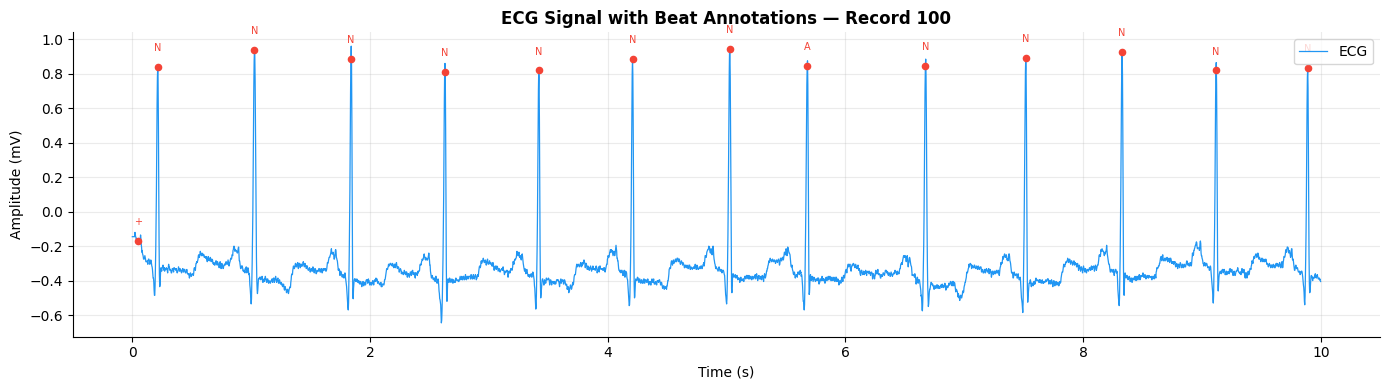

In [7]:
PREVIEW_RECORD = "100"
PREVIEW_DURATION = 10  # seconds

record = wfdb.rdrecord(
    os.path.join(DATA_DIR, PREVIEW_RECORD)
)

annotation = wfdb.rdann(
    os.path.join(DATA_DIR, PREVIEW_RECORD),
    "atr"
)

signal  = record.p_signal[:, 0]
fs      = record.fs
t       = np.arange(len(signal)) / fs
samples = int(PREVIEW_DURATION * fs)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t[:samples], signal[:samples], color="#2196F3", linewidth=0.9, label="ECG")

for s, sym in zip(annotation.sample, annotation.symbol):
    if s < samples:
        ax.scatter(s / fs, signal[s], color="#F44336", s=20, zorder=3)
        ax.text(s / fs, signal[s] + 0.08, sym, fontsize=7, color="#F44336",
                ha="center", va="bottom")

ax.set_title(f"ECG Signal with Beat Annotations — Record {PREVIEW_RECORD}",
             fontweight="bold")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (mV)")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 2. Data Preparation & Labelling

Each record is filtered with a **0.5–40 Hz bandpass** to remove baseline wander and high-frequency noise. Beats are segmented around annotated R-peaks with a fixed window of **200 ms pre** and **400 ms post** the peak.

Raw MIT-BIH symbols are mapped to the 5-class AAMI grouping before saving.

### Dataset Selection and Lead Standardization

To ensure a consistent ECG input and follow the conventional non-pacemaker evaluation setting, the four MIT-BIH recordings containing paced beats (102, 104, 107, and 217) were excluded. From the remaining recordings, the MLII channel was explicitly selected whenever available rather than assuming that the first recorded channel was MLII. Recordings without an MLII channel were excluded from further processing. The selected MLII signals were then band-pass filtered using the same fourth-order Butterworth filter (0.5–40 Hz) and segmented into 600-ms heartbeat windows centered on the annotated R-peaks. The existing AAMI beat-label mapping was retained for classification into the five classes: N, S, V, F, and Q.

In [8]:
PACED_RECORDS = {"102", "104", "107", "217"}

RECORD_IDS = [
    rec for rec in RECORD_IDS
    if rec not in PACED_RECORDS
]

In [9]:
LABEL_MAP = {
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    "A": "S", "a": "S", "J": "S", "S": "S",
    "V": "V", "E": "V",
    "F": "F",
    "/": "Q", "f": "Q", "Q": "Q", "x": "Q", "X": "Q",
}

LABEL_FULL = {
    "N": "Normal",
    "S": "Supraventricular",
    "V": "Ventricular",
    "F": "Fusion",
    "Q": "Unknown / Paced"
}

CLASS_COLORS = {
    "N": "#2196F3",
    "S": "#4CAF50",
    "V": "#F44336",
    "F": "#FF9800",
    "Q": "#9C27B0"
}


def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, signal)


os.makedirs("data/processed", exist_ok=True)

OUT_BEATS = "data/processed/beats.npy"
OUT_LABELS = "data/processed/labels.npy"


def preprocess_ecg(record_path, window_pre=0.2, window_post=0.4):
    try:
        rec = wfdb.rdrecord(record_path)
        ann = wfdb.rdann(record_path, "atr")

        if "MLII" not in rec.sig_name:
            return np.array([], dtype=np.float32), np.array([])

        ml2_index = rec.sig_name.index("MLII")
        sig = bandpass_filter(rec.p_signal[:, ml2_index], rec.fs)

        wp = int(window_pre * rec.fs)
        ws = int(window_post * rec.fs)

        beats, labels = [], []

        for r, lbl in zip(ann.sample, ann.symbol):
            if lbl not in LABEL_MAP:
                continue

            if r - wp >= 0 and r + ws < len(sig):
                beats.append(sig[r - wp : r + ws])
                labels.append(LABEL_MAP[lbl])

        return np.array(beats, dtype=np.float32), np.array(labels)

    except Exception as e:
        print(f"Error in {record_path}: {e}")
        return np.array([], dtype=np.float32), np.array([])


all_beats, all_labels = [], []

for rec in RECORD_IDS:
    beats, labels = preprocess_ecg(os.path.join(DATA_DIR, rec))

    if beats.size > 0:
        all_beats.append(beats)
        all_labels.append(labels)
        print(f"{rec}: {len(beats):,} beats")

if not all_beats:
    raise RuntimeError("No beats extracted. Check DATA_DIR and record files.")

all_beats = np.vstack(all_beats)
all_labels = np.concatenate(all_labels)

print(f"\nTotal beats: {len(all_beats):,}")
print(f"Label distribution: {Counter(all_labels)}")

np.save(OUT_BEATS, all_beats)
np.save(OUT_LABELS, all_labels)

print(f"\nSaved -> {OUT_BEATS}, {OUT_LABELS}")

100: 2,272 beats
101: 1,865 beats
103: 2,083 beats
105: 2,572 beats
106: 2,027 beats
108: 1,774 beats
109: 2,531 beats
111: 2,124 beats
112: 2,538 beats
113: 1,794 beats
114: 1,879 beats
115: 1,952 beats
116: 2,411 beats
117: 1,534 beats
118: 2,287 beats
119: 1,987 beats
121: 1,862 beats
122: 2,475 beats
123: 1,517 beats
124: 1,618 beats
200: 2,600 beats
201: 2,000 beats
202: 2,135 beats
203: 2,980 beats
205: 2,655 beats
207: 1,859 beats
208: 2,953 beats
209: 3,004 beats
210: 2,648 beats
212: 2,747 beats
213: 3,250 beats
214: 2,260 beats
215: 3,362 beats
219: 2,287 beats
220: 2,046 beats
221: 2,427 beats
222: 2,482 beats
223: 2,605 beats
228: 2,053 beats
230: 2,256 beats
231: 1,572 beats
232: 1,780 beats
233: 3,077 beats
234: 2,753 beats

Total beats: 100,893
Label distribution: Counter({'N': 90094, 'V': 7008, 'S': 2781, 'F': 802, 'Q': 208})

Saved -> data/processed/beats.npy, data/processed/labels.npy


### 2.1 Preprocessing Visualization

The plots below show raw ECG data, the bandpass-filtered signal, and the final beat segment used for modelling. This lets you inspect the full preprocessing pipeline step by step for one representative R-peak.

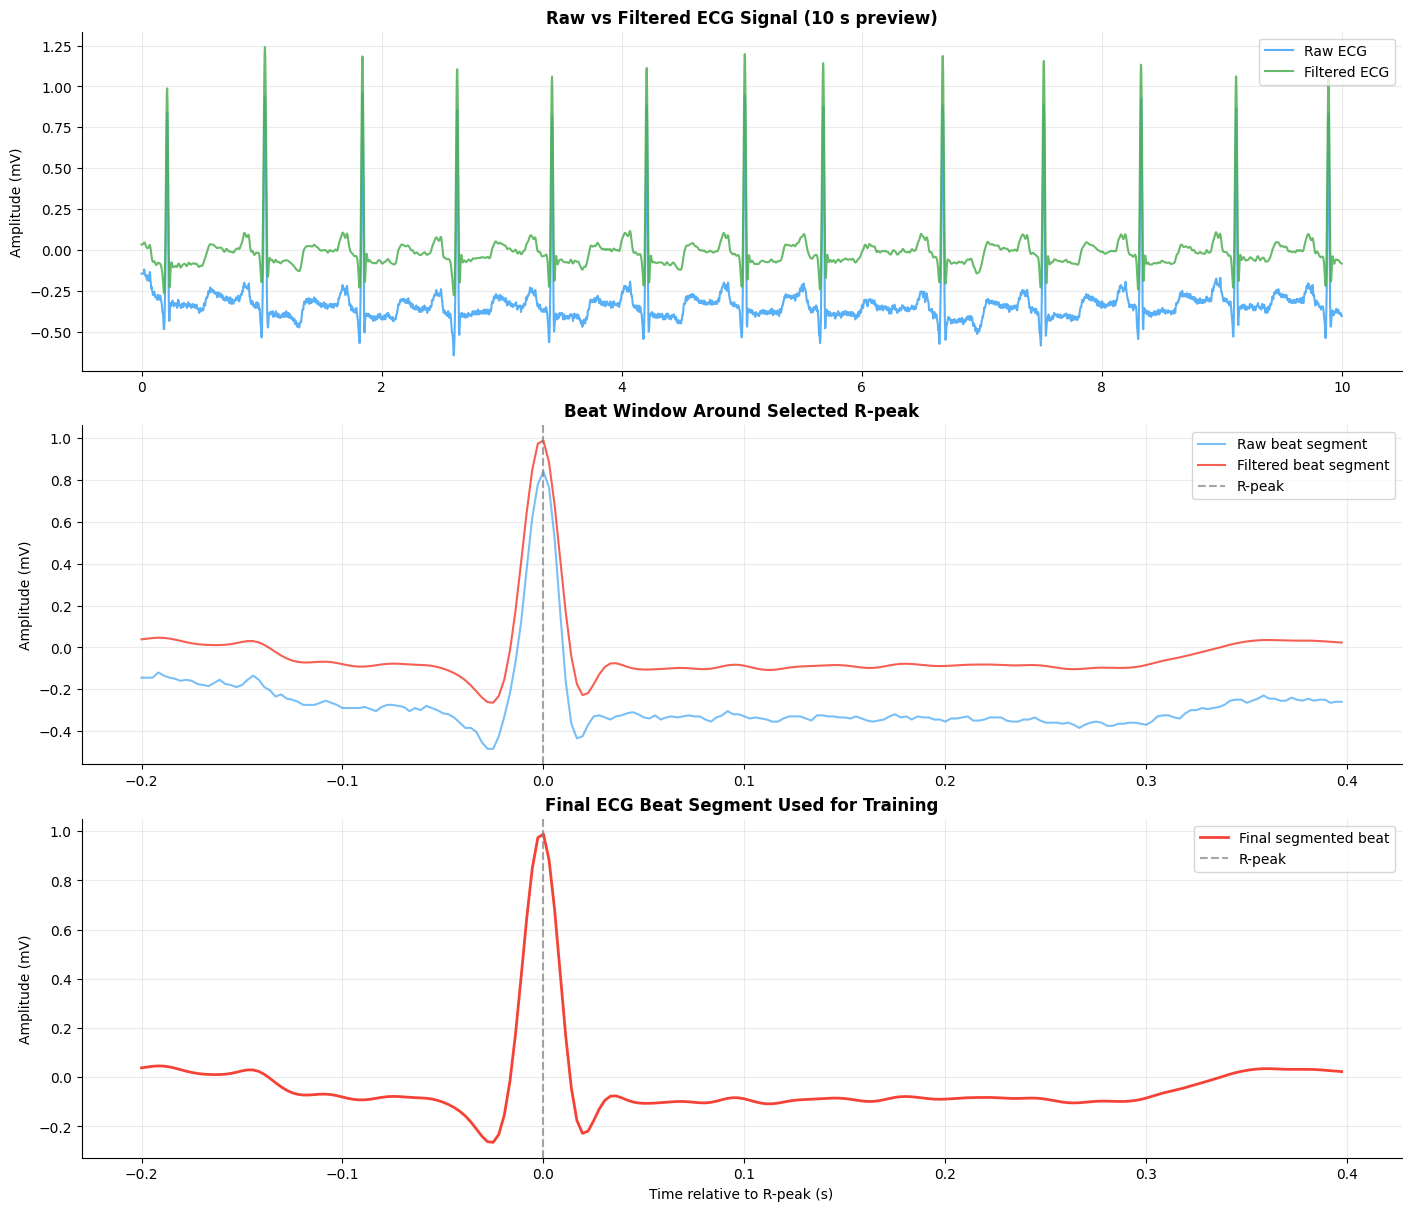

In [10]:
# Visualize raw → filtered → segmented ECG for one representative beat
record          = wfdb.rdrecord(PREVIEW_RECORD, pn_dir="mitdb")
ann             = wfdb.rdann(PREVIEW_RECORD, "atr", pn_dir="mitdb")
raw_signal      = record.p_signal[:, 0]
filtered_signal = bandpass_filter(raw_signal, record.fs)

window_pre  = int(0.2 * record.fs)
window_post = int(0.4 * record.fs)
samples     = int(PREVIEW_DURATION * record.fs)

valid_beats = [s for s in ann.sample if s >= window_pre and s + window_post < len(filtered_signal)]
beat_center = valid_beats[0] if valid_beats else ann.sample[0]

beat_start = beat_center - window_pre
beat_end   = beat_center + window_post

t_full    = np.arange(samples) / record.fs
t_segment = np.arange(len(filtered_signal[beat_start:beat_end])) / record.fs - 0.2

fig, axs = plt.subplots(3, 1, figsize=(14, 12), constrained_layout=True)

axs[0].plot(t_full, raw_signal[:samples], label="Raw ECG", color="#2196F3", alpha=0.75)
axs[0].plot(t_full, filtered_signal[:samples], label="Filtered ECG", color="#4CAF50", alpha=0.85)
axs[0].set_title("Raw vs Filtered ECG Signal (10 s preview)", fontweight="bold")
axs[0].set_ylabel("Amplitude (mV)")
axs[0].grid(alpha=0.25)
axs[0].legend(loc="upper right")
axs[0].spines[["top", "right"]].set_visible(False)

axs[1].plot(t_segment, raw_signal[beat_start:beat_end], label="Raw beat segment", color="#2196F3", alpha=0.6)
axs[1].plot(t_segment, filtered_signal[beat_start:beat_end], label="Filtered beat segment", color="#F44336", alpha=0.85)
axs[1].axvline(0.0, color="grey", linestyle="--", alpha=0.7, label="R-peak")
axs[1].set_title("Beat Window Around Selected R-peak", fontweight="bold")
axs[1].set_ylabel("Amplitude (mV)")
axs[1].legend(loc="upper right")
axs[1].grid(alpha=0.25)
axs[1].spines[["top", "right"]].set_visible(False)

axs[2].plot(t_segment, filtered_signal[beat_start:beat_end], label="Final segmented beat", color="#F44336", linewidth=2)
axs[2].axvline(0.0, color="grey", linestyle="--", alpha=0.7, label="R-peak")
axs[2].set_title("Final ECG Beat Segment Used for Training", fontweight="bold")
axs[2].set_xlabel("Time relative to R-peak (s)")
axs[2].set_ylabel("Amplitude (mV)")
axs[2].legend(loc="upper right")
axs[2].grid(alpha=0.25)
axs[2].spines[["top", "right"]].set_visible(False)

plt.show()

### 2.2 Beat Sample Visualisation

One representative beat per class to verify segmentation quality and observe morphological differences. The dashed grey line marks the R-peak position.

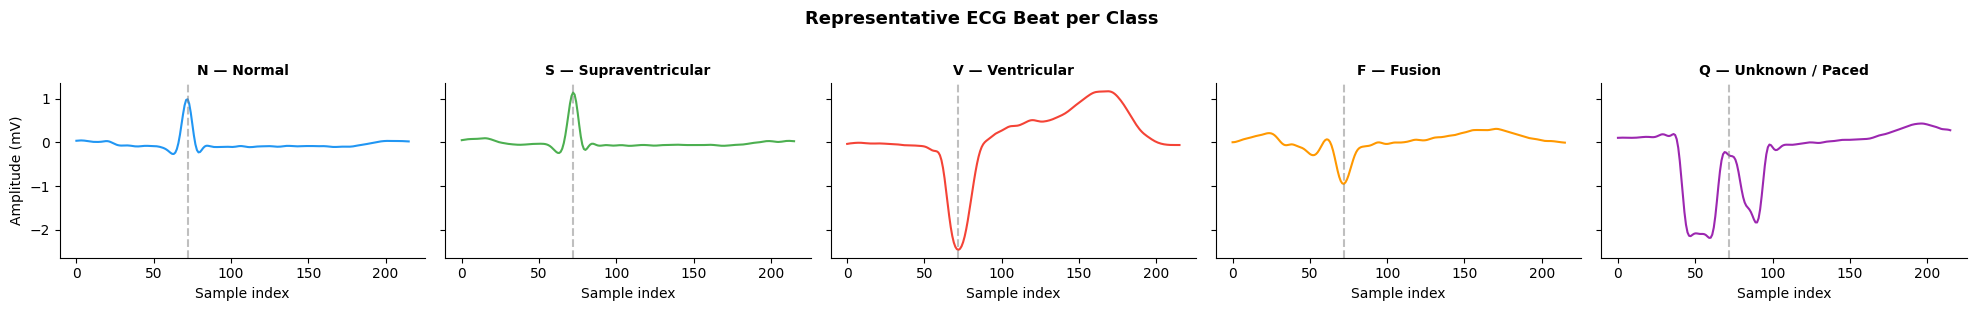

In [11]:
beats  = np.load(OUT_BEATS)
labels = np.load(OUT_LABELS)
classes = [c for c in ["N", "S", "V", "F", "Q"] if c in labels]

fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 3), sharey=True)
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    beat   = beats[np.where(labels == cls)[0][0]]
    t      = np.arange(len(beat))
    r_peak = int(len(beat) * 0.2 / 0.6)

    ax.plot(t, beat, color=CLASS_COLORS[cls], linewidth=1.5)
    ax.axvline(r_peak, color="grey", linestyle="--", alpha=0.5, label="R-peak")
    ax.set_title(f"{cls} — {LABEL_FULL[cls]}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Sample index")
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Amplitude (mV)")
fig.suptitle("Representative ECG Beat per Class", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. CNN Model Definition & Training

Architecture: three `Conv1D -> BatchNorm -> Pooling` blocks followed by `GlobalAveragePooling1D` and a `Dense` head with dropout.

| Block | Filters | Kernel | Pooling |
|-------|---------|--------|---------|
| 1 | 32 | 7 | MaxPool(2) |
| 2 | 64 | 5 | MaxPool(2) |
| 3 | 128 | 3 | GlobalAvgPool |

Training uses **class weighting**, **early stopping** (patience = 5), and a **model checkpoint** to keep the best validation-loss epoch.

In [12]:
# Load & encode
X = np.load(OUT_BEATS)[..., np.newaxis]   # (N, seq_len, 1)
y = np.load(OUT_LABELS)

# Drop classes with fewer than MIN_SAMPLES samples, then re-encode
MIN_SAMPLES  = 5
keep_labels  = [lbl for lbl, n in Counter(y).items() if n >= MIN_SAMPLES]
keep         = np.isin(y, keep_labels)
X, y         = X[keep], y[keep]

encoder     = LabelEncoder()
y_enc       = encoder.fit_transform(y)
num_classes = len(encoder.classes_)

np.save("data/processed/label_classes.npy", encoder.classes_)
print(f"Classes ({num_classes}): {encoder.classes_}")
print(f"Total samples: {len(X):,}")

# Train / val / test split (80 / 10 / 10)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.20, stratify=y_enc, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
print(f"Split -- Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_cat   = tf.keras.utils.to_categorical(y_val,   num_classes)

cw_dict = dict(enumerate(
    compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
))


def build_cnn(input_shape, num_classes):
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv1D(32,  7, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(64,  5, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),

        tf.keras.layers.Conv1D(128, 3, padding="same", activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="ECG_CNN")


model = build_cnn(X_train.shape[1:], num_classes)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/cnn_ecg_best.keras", save_best_only=True
    ),
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1,
)

model.save("models/cnn_ecg_final.keras")
print("Saved -> models/cnn_ecg_final.keras")

Classes (5): ['F' 'N' 'Q' 'S' 'V']
Total samples: 100,893
Split -- Train: 80,714  Val: 10,089  Test: 10,090


Model: "ECG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 216, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 216, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 108, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 108, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 54, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 54, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 54, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,317 (208.27 KB)

 Trainable params: 52,869 (206.52 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.5286 - loss: 0.8994 - val_accuracy: 0.3666 - val_loss: 1.4086
Epoch 2/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6777 - loss: 0.5895 - val_accuracy: 0.8604 - val_loss: 0.5532
Epoch 3/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7605 - loss: 0.4717 - val_accuracy: 0.8855 - val_loss: 0.4958
Epoch 4/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7977 - loss: 0.4184 - val_accuracy: 0.7909 - val_loss: 0.7199
Epoch 5/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8146 - loss: 0.3761 - val_accuracy: 0.7998 - val_loss: 0.6102
Epoch 6/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8464 - loss: 0.3114 - val_accuracy: 0.7627 - val_loss: 0.6374
Epoch 7/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8382 - loss: 0.3281 - val_accuracy: 0.8799 - val_loss: 0.3875
Epoch 8/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8600 - loss:

In [13]:
def build_cnn(input_shape, num_classes, filters, kernels, dense_units=128, dropout=0.4):
    layers = [
        tf.keras.layers.Input(shape=input_shape)
    ]

    for f, k in zip(filters, kernels):
        layers.extend([
            tf.keras.layers.Conv1D(f, k, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.MaxPooling1D(2)
        ])

    layers.extend([
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(dense_units, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    return tf.keras.Sequential(layers, name="ECG_CNN")


architectures = {
    "A_small": {
        "filters": [16, 32, 64],
        "kernels": [7, 5, 3]
    },
    "B_baseline": {
        "filters": [32, 64, 128],
        "kernels": [7, 5, 3]
    },
    "C_deep": {
        "filters": [32, 64, 128, 256],
        "kernels": [7, 5, 3, 3]
    }
}


results = {}

for name, config in architectures.items():

    print(f"\n{'=' * 60}")
    print(f"Training {name}")
    print(f"{'=' * 60}")

    model = build_cnn(
        X_train.shape[1:],
        num_classes,
        filters=config["filters"],
        kernels=config["kernels"]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=30,
        batch_size=64,
        class_weight=cw_dict,
        callbacks=[early_stopping],
        verbose=1
    )

    val_probs = model.predict(X_val, verbose=0)
    val_pred = np.argmax(val_probs, axis=1)

    results[name] = {
        "model": model,
        "history": history,
        "val_macro_f1": f1_score(
            y_val,
            val_pred,
            average="macro"
        ),
        "val_accuracy": accuracy_score(
            y_val,
            val_pred
        )
    }

    print(
        f"{name}: "
        f"Val Accuracy = {results[name]['val_accuracy']:.4f}, "
        f"Val Macro-F1 = {results[name]['val_macro_f1']:.4f}"
    )


print("\nArchitecture comparison")
print("=" * 60)

for name, result in results.items():
    print(
        f"{name:12s} | "
        f"Accuracy: {result['val_accuracy']:.4f} | "
        f"Macro-F1: {result['val_macro_f1']:.4f}"
    )


Training A_small
Epoch 1/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5963 - loss: 0.7699 - val_accuracy: 0.6056 - val_loss: 0.9150
Epoch 2/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7073 - loss: 0.5636 - val_accuracy: 0.8299 - val_loss: 0.6053
Epoch 3/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7743 - loss: 0.4505 - val_accuracy: 0.8290 - val_loss: 0.5030
Epoch 4/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8109 - loss: 0.3855 - val_accuracy: 0.8020 - val_loss: 0.5348
Epoch 5/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8261 - loss: 0.3561 - val_accuracy: 0.8522 - val_loss: 0.4995
Epoch 6/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8422 - loss: 0.3009 - val_accuracy: 0.8488 - val_loss: 0.4470
Epoch 7/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8556 - loss: 0.2863 - val_accuracy: 0.8808 - val_loss: 0.3675
Epoch 8/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accur

In [24]:
import random
import keras_tuner as kt
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


class MacroF1Callback(tf.keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs=None):
        val_probs = self.model.predict(X_val, verbose=0)
        val_pred = np.argmax(val_probs, axis=1)

        macro_f1 = f1_score(
            y_val,
            val_pred,
            average="macro"
        )

        logs["val_macro_f1"] = macro_f1


def build_tuned_cnn(hp):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=X_train.shape[1:])
    ])

    num_blocks = hp.Int(
        "num_blocks",
        min_value=2,
        max_value=4,
        step=1
    )

    base_filters = hp.Choice(
        "base_filters",
        values=[16, 32, 64]
    )

    kernel_size = hp.Choice(
        "kernel_size",
        values=[3, 5, 7, 9, 11]
    )

    for i in range(num_blocks):

        filters = base_filters * (2 ** i)

        model.add(
            tf.keras.layers.Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                padding="same",
                activation="relu"
            )
        )

        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.MaxPooling1D(2))

    model.add(tf.keras.layers.GlobalAveragePooling1D())

    dense_units = hp.Choice(
        "dense_units",
        values=[64, 128, 256]
    )

    dropout = hp.Float(
        "dropout",
        min_value=0.2,
        max_value=0.5,
        step=0.1
    )

    model.add(
        tf.keras.layers.Dense(
            dense_units,
            activation="relu"
        )
    )

    model.add(
        tf.keras.layers.Dropout(dropout)
    )

    model.add(
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax"
        )
    )

    learning_rate = hp.Float(
        "learning_rate",
        min_value=1e-4,
        max_value=1e-3,
        sampling="log"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tuner = kt.RandomSearch(
    build_tuned_cnn,
    objective=kt.Objective(
        "val_macro_f1",
        direction="max"
    ),
    max_trials=15,
    executions_per_trial=1,
    directory="models/tuning",
    project_name="ecg_cnn",
    overwrite=True,
    seed=SEED
)


tuner.search(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=[
        MacroF1Callback(),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Trial 15 Complete [00h 08m 39s]
val_macro_f1: 0.8491015018696583

Best val_macro_f1 So Far: 0.8966847839543826
Total elapsed time: 01h 59m 03s


In [25]:
results = tuner.results_summary(num_trials=15)

Results summary
Results in models/tuning\ecg_cnn
Showing 15 best trials
Objective(name="val_macro_f1", direction="max")

Trial 07 summary
Hyperparameters:
num_blocks: 4
base_filters: 16
kernel_size: 9
dense_units: 64
dropout: 0.30000000000000004
learning_rate: 0.00012052875335643394
Score: 0.8966847839543826

Trial 06 summary
Hyperparameters:
num_blocks: 4
base_filters: 16
kernel_size: 5
dense_units: 128
dropout: 0.2
learning_rate: 0.00031344126384632453
Score: 0.8917891951105172

Trial 14 summary
Hyperparameters:
num_blocks: 3
base_filters: 16
kernel_size: 11
dense_units: 128
dropout: 0.30000000000000004
learning_rate: 0.00020674508263974638
Score: 0.8491015018696583

Trial 13 summary
Hyperparameters:
num_blocks: 3
base_filters: 16
kernel_size: 7
dense_units: 64
dropout: 0.4
learning_rate: 0.0007944347251838391
Score: 0.7891379812209391

Trial 02 summary
Hyperparameters:
num_blocks: 4
base_filters: 16
kernel_size: 11
dense_units: 64
dropout: 0.30000000000000004
learning_rate: 0.000167

In [26]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
for name, value in best_hp.values.items():
    print(f"{name}: {value}")

Best hyperparameters:
num_blocks: 4
base_filters: 16
kernel_size: 9
dense_units: 64
dropout: 0.30000000000000004
learning_rate: 0.00012052875335643394


In [27]:
best_model = tuner.get_best_models(num_models=1)[0]

val_probs = best_model.predict(X_val, verbose=0)
val_pred = np.argmax(val_probs, axis=1)

val_f1 = f1_score(
    y_val,
    val_pred,
    average=None
)

print("Validation results")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_val, val_pred):.4f}")
print(f"Macro-F1 : {f1_score(y_val, val_pred, average='macro'):.4f}")

for label, score in zip(encoder.classes_, val_f1):
    print(f"{label} F1     : {score:.4f}")

c:\Users\siria\anaconda3\envs\ecg_tf\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(store)


Validation results
Accuracy : 0.9860
Macro-F1 : 0.8967
F F1     : 0.8222
N F1     : 0.9932
Q F1     : 0.8372
S F1     : 0.8602
V F1     : 0.9707


In [28]:
BEST_CONFIG = {
    "num_blocks": 4,
    "base_filters": 16,
    "kernel_size": 11,
    "dense_units": 64,
    "dropout": 0.3,
    "learning_rate": 0.00016756583493598323
}


def build_final_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape)
    ])

    for i in range(BEST_CONFIG["num_blocks"]):
        model.add(
            tf.keras.layers.Conv1D(
                BEST_CONFIG["base_filters"] * (2 ** i),
                BEST_CONFIG["kernel_size"],
                padding="same",
                activation="relu"
            )
        )
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.MaxPooling1D(2))

    model.add(tf.keras.layers.GlobalAveragePooling1D())

    model.add(
        tf.keras.layers.Dense(
            BEST_CONFIG["dense_units"],
            activation="relu"
        )
    )

    model.add(
        tf.keras.layers.Dropout(
            BEST_CONFIG["dropout"]
        )
    )

    model.add(
        tf.keras.layers.Dense(
            num_classes,
            activation="softmax"
        )
    )

    return model


final_model = build_final_cnn(
    X_train.shape[1:],
    num_classes
)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=BEST_CONFIG["learning_rate"]
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

final_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 216, 16)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 216, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 108, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 108, 32)        │         5,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 108, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 54, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 54, 64)         │        22,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 54, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 27, 128)        │        90,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 27, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,229 (500.89 KB)

 Trainable params: 127,749 (499.02 KB)

 Non-trainable params: 480 (1.88 KB)

In [29]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_final = final_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=[early_stopping],
    verbose=1
)

final_model.save("models/cnn_ecg_tuned.keras")

print("Saved -> models/cnn_ecg_tuned.keras")

Epoch 1/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.7290 - loss: 0.5716 - val_accuracy: 0.8841 - val_loss: 0.4460
Epoch 2/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.8598 - loss: 0.3224 - val_accuracy: 0.8941 - val_loss: 0.3760
Epoch 3/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.8930 - loss: 0.2520 - val_accuracy: 0.8923 - val_loss: 0.3457
Epoch 4/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9082 - loss: 0.2045 - val_accuracy: 0.8698 - val_loss: 0.4007
Epoch 5/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9165 - loss: 0.1748 - val_accuracy: 0.9156 - val_loss: 0.2939
Epoch 6/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9261 - loss: 0.1580 - val_accuracy: 0.9506 - val_loss: 0.1786
Epoch 7/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9357 - loss: 0.1349 - val_accuracy: 0.9462 - val_loss: 0.1788
Epoch 8/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.9434 -

### 3.1 Training Curves

Loss and accuracy over epochs. The dashed line marks the best epoch chosen by early stopping.

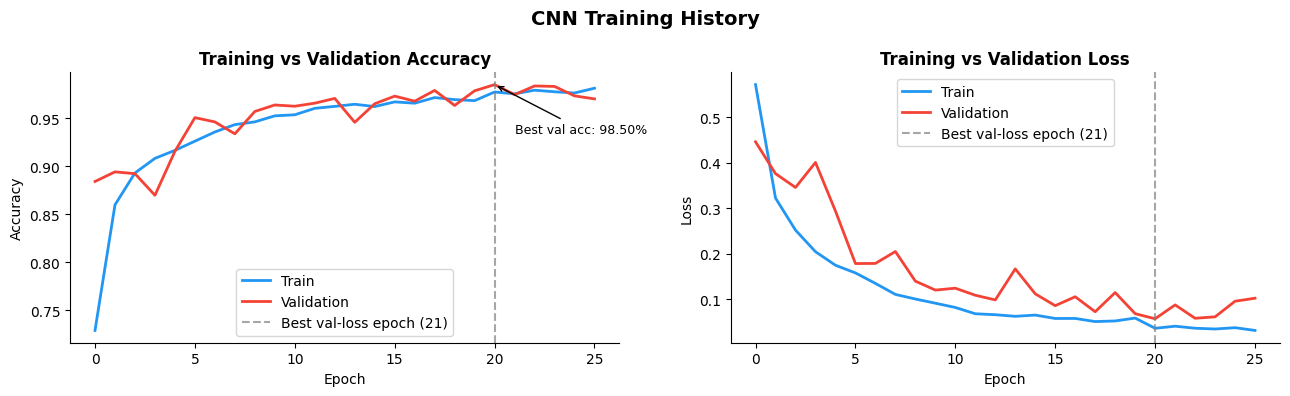

In [30]:
best_epoch = int(np.argmin(history_final.history["val_loss"]))

final_val_acc = history_final.history["val_accuracy"][best_epoch]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in [
    (ax1, "accuracy", "Accuracy"),
    (ax2, "loss", "Loss")
]:
    ax.plot(
        history_final.history[metric],
        label="Train",
        color="#2196F3",
        linewidth=2
    )

    ax.plot(
        history_final.history[f"val_{metric}"],
        label="Validation",
        color="#F44336",
        linewidth=2
    )

    ax.axvline(
        best_epoch,
        color="grey",
        linestyle="--",
        alpha=0.7,
        label=f"Best val-loss epoch ({best_epoch + 1})"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.set_title(
        f"Training vs Validation {title}",
        fontweight="bold"
    )
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

ax1.annotate(
    f"Best val acc: {final_val_acc:.2%}",
    xy=(best_epoch, final_val_acc),
    xytext=(best_epoch + 1, final_val_acc - 0.05),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9
)

fig.suptitle(
    "CNN Training History",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 4. Model Evaluation

The best checkpoint is evaluated on the held-out test set. Metrics: **precision**, **recall**, **F1-score** per class, plus annotated confusion matrices (raw counts and row-normalised recall).

In [31]:
best_model = tf.keras.models.load_model("models/cnn_ecg_tuned.keras", compile=False)

y_pred_probs         = best_model.predict(X_test, verbose=0)
y_pred               = np.argmax(y_pred_probs, axis=1)
y_true               = y_test
labels_present       = np.unique(y_true)
target_names_present = encoder.classes_[labels_present]
overall_acc          = np.mean(y_true == y_pred)

print("Classification Report\n" + "=" * 50)
print(classification_report(
    y_true, y_pred,
    labels=labels_present,
    target_names=target_names_present,
    digits=4,
))
print(f"Overall Test Accuracy: {overall_acc:.4f}")

Classification Report
              precision    recall  f1-score   support

           F     0.6471    0.9625    0.7739        80
           N     0.9974    0.9892    0.9933      9010
           Q     0.8182    0.8571    0.8372        21
           S     0.8117    0.9460    0.8738       278
           V     0.9811    0.9643    0.9727       701

    accuracy                         0.9858     10090
   macro avg     0.8511    0.9439    0.8902     10090
weighted avg     0.9880    0.9858    0.9865     10090

Overall Test Accuracy: 0.9858


### 4.1 Confusion Matrix

Saved → images/confusion_matrix_normalised.png


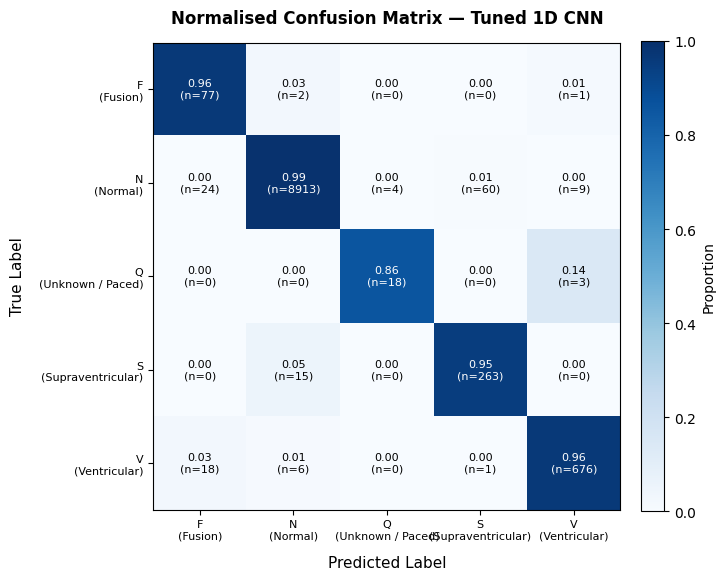

In [33]:
# ── Publication Figure 1: Normalised 5×5 Confusion Matrix ─────────────────
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalise

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Proportion")

tick_labels = [f"{encoder.classes_[i]}\n({LABEL_FULL[encoder.classes_[i]]})"
               for i in range(len(encoder.classes_))]
ax.set_xticks(range(len(encoder.classes_)))
ax.set_yticks(range(len(encoder.classes_)))
ax.set_xticklabels(tick_labels, fontsize=8)
ax.set_yticklabels(tick_labels, fontsize=8)

# Annotate every cell with both the proportion and the raw count
for i, j in itertools.product(range(cm_norm.shape[0]), range(cm_norm.shape[1])):
    color = "white" if cm_norm[i, j] > 0.6 else "black"
    ax.text(j, i,
            f"{cm_norm[i, j]:.2f}\n(n={cm[i, j]})",
            ha="center", va="center", fontsize=8, color=color)

ax.set_xlabel("Predicted Label", fontsize=11, labelpad=10)
ax.set_ylabel("True Label", fontsize=11, labelpad=10)
ax.set_title("Normalised Confusion Matrix — Tuned 1D CNN",
             fontsize=12, fontweight="bold", pad=14)

fig.tight_layout()
os.makedirs("images", exist_ok=True)
fig.savefig("images/confusion_matrix_normalised.png", dpi=300, bbox_inches="tight")
print("Saved → images/confusion_matrix_normalised.png")
plt.show()

### 4.2 Per-Class Confidence Distribution

Softmax probability assigned to the **true class** for each test sample. A high median and tight spread indicates the model is reliably confident when it is correct.

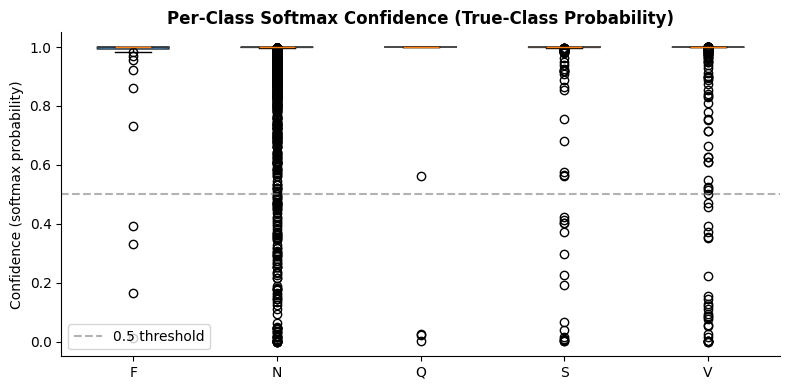

In [34]:
conf_per_class = [y_pred_probs[y_true == lbl, lbl] for lbl in labels_present]
palette        = ["#2196F3", "#4CAF50", "#F44336", "#FF9800", "#9C27B0"]

fig, ax = plt.subplots(figsize=(8, 4))

bp = ax.boxplot(conf_per_class, patch_artist=True, notch=True)
for patch, col in zip(bp["boxes"], palette):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(target_names_present) + 1))
ax.set_xticklabels(target_names_present)
ax.set_ylabel("Confidence (softmax probability)")
ax.set_title("Per-Class Softmax Confidence (True-Class Probability)", fontweight="bold")
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.6, label="0.5 threshold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### 4A. ROC-AUC Metrics

Macro-averaged One-vs-Rest ROC-AUC is the standard robustness metric for medical classifiers. It measures class separability regardless of the decision threshold and is insensitive to class imbalance.

A score ≥ 0.97 is considered **exceptional** in the arrhythmia-classification literature.

Macro-averaged ROC-AUC (OvR): 0.9986

Per-class AUC:
  F (Fusion): 0.9990
  N (Normal): 0.9983
  Q (Unknown / Paced): 0.9994
  S (Supraventricular): 0.9972
  V (Ventricular): 0.9990
Saved → images/roc_curves.png


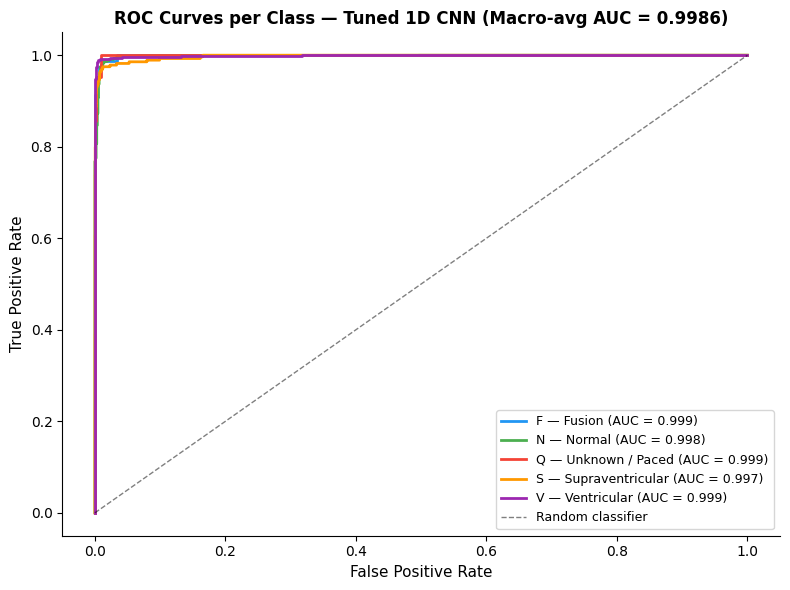

In [35]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# ── Macro-averaged OvR ROC-AUC ───────────────────────────────────────────
# y_pred_probs shape: (n_test, num_classes) — already computed in cell 18
from tensorflow.keras.utils import to_categorical
y_true_cat = to_categorical(y_true, num_classes=num_classes)

auc_macro = roc_auc_score(y_true_cat, y_pred_probs, multi_class='ovr', average='macro')
auc_per_class = roc_auc_score(y_true_cat, y_pred_probs, multi_class='ovr', average=None)

print(f"Macro-averaged ROC-AUC (OvR): {auc_macro:.4f}")
print("\nPer-class AUC:")
for cls_name, auc in zip(encoder.classes_, auc_per_class):
    print(f"  {cls_name} ({LABEL_FULL[cls_name]}): {auc:.4f}")

# ── Plot ROC curve per class ──────────────────────────────────────────────
palette = ["#2196F3", "#4CAF50", "#F44336", "#FF9800", "#9C27B0"]
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls_name, color) in enumerate(zip(encoder.classes_, palette)):
    fpr, tpr, _ = roc_curve(y_true_cat[:, i], y_pred_probs[:, i])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{cls_name} — {LABEL_FULL[cls_name]} (AUC = {auc_per_class[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'ROC Curves per Class — Tuned 1D CNN '
    f'(Macro-avg AUC = {auc_macro:.4f})',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
os.makedirs('images', exist_ok=True)
fig.savefig('images/roc_curves.png', dpi=300, bbox_inches='tight')
print("Saved → images/roc_curves.png")
plt.show()

### 4B. Confidence Intervals via Test-Set Bootstrapping

To demonstrate that the reported accuracy is statistically stable rather than a product of a single lucky train-test split, we apply **1,000-iteration bootstrap resampling** on the held-out test set. The 2.5th and 97.5th percentiles of the resulting distribution yield a 95% confidence interval.

Bootstrap Results (1000 iterations)
  Point estimate : 98.58%
  95% CI         : 98.3% – 98.8%
  Std dev        : 0.12%
Saved → images/bootstrap_ci.png


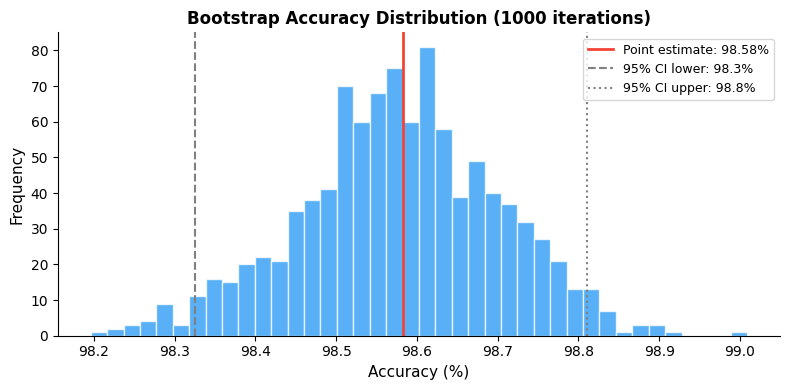

In [36]:
from sklearn.utils import resample

# ── Bootstrap CI on test-set accuracy ────────────────────────────────────
N_BOOTSTRAP = 1000
rng_seed = 42
boot_accs = []

rng_bs = np.random.default_rng(rng_seed)
n_test = len(y_true)

for _ in range(N_BOOTSTRAP):
    indices = rng_bs.integers(0, n_test, size=n_test)
    boot_acc = np.mean(y_true[indices] == y_pred[indices])
    boot_accs.append(boot_acc)

boot_accs = np.array(boot_accs)

ci_lower = np.percentile(boot_accs, 2.5)
ci_upper = np.percentile(boot_accs, 97.5)

print(f"Bootstrap Results ({N_BOOTSTRAP} iterations)")
print(f"  Point estimate : {overall_acc * 100:.2f}%")
print(f"  95% CI         : {ci_lower * 100:.1f}% – {ci_upper * 100:.1f}%")
print(f"  Std dev        : {boot_accs.std() * 100:.2f}%")

# ── Plot bootstrap distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    boot_accs * 100,
    bins=40,
    color="#2196F3",
    alpha=0.75,
    edgecolor="white"
)

ax.axvline(
    overall_acc * 100,
    color="#F44336",
    linewidth=2,
    label=f"Point estimate: {overall_acc * 100:.2f}%"
)

ax.axvline(
    ci_lower * 100,
    color="grey",
    linewidth=1.5,
    linestyle="--",
    label=f"95% CI lower: {ci_lower * 100:.1f}%"
)

ax.axvline(
    ci_upper * 100,
    color="grey",
    linewidth=1.5,
    linestyle=":",
    label=f"95% CI upper: {ci_upper * 100:.1f}%"
)

ax.set_xlabel("Accuracy (%)", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.set_title(
    f"Bootstrap Accuracy Distribution ({N_BOOTSTRAP} iterations)",
    fontsize=12,
    fontweight="bold"
)

ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

fig.savefig(
    "images/bootstrap_ci.png",
    dpi=300,
    bbox_inches="tight"
)

print("Saved → images/bootstrap_ci.png")
plt.show()

### 4C. Ablation Study — Butterworth Filter

An ablation study validates each design choice by removing it and measuring the resulting performance degradation. Here we train an **identical CNN** on *raw, unfiltered* ECG beats (no Butterworth bandpass, no baseline-wander removal) and compare its metrics to the baseline filtered model.

> **Expected outcome:** removing the filter should hurt minority-class F1 (especially Supraventricular beats) more than majority-class accuracy, because morphological features of low-amplitude classes are buried in baseline wander.

In [37]:
# ── Ablation: raw (unfiltered) preprocessing ──────────────────────────────
print("Building ablation dataset (raw, unfiltered beats)...")

def preprocess_ecg_raw(record_path, window_pre=0.2, window_post=0.4):
    try:
        rec = wfdb.rdrecord(record_path)
        ann = wfdb.rdann(record_path, "atr")

        if "MLII" not in rec.sig_name:
            return np.array([], dtype=np.float32), np.array([])

        ml2_index = rec.sig_name.index("MLII")
        sig = rec.p_signal[:, ml2_index]

        wp = int(window_pre * rec.fs)
        ws = int(window_post * rec.fs)

        beats, labels = [], []

        for r, lbl in zip(ann.sample, ann.symbol):
            if lbl not in LABEL_MAP:
                continue

            if r - wp >= 0 and r + ws < len(sig):
                beats.append(sig[r - wp:r + ws])
                labels.append(LABEL_MAP[lbl])

        return np.array(beats, dtype=np.float32), np.array(labels)

    except Exception as e:
        print(f"Error in {record_path}: {e}")
        return np.array([], dtype=np.float32), np.array([])


raw_beats_all, raw_labels_all = [], []

for rec in RECORD_IDS:
    b, l = preprocess_ecg_raw(os.path.join(DATA_DIR, rec))

    if b.size > 0:
        raw_beats_all.append(b)
        raw_labels_all.append(l)

raw_beats_all = np.vstack(raw_beats_all)
raw_labels_all = np.concatenate(raw_labels_all)

print(f"Raw ablation dataset: {len(raw_beats_all):,} beats")


# ── Same encoding and 80/10/10 split ─────────────────────────────────────
X_raw = raw_beats_all[..., np.newaxis]
y_raw = encoder.transform(raw_labels_all)

X_raw_tr, X_raw_tmp, y_raw_tr, y_raw_tmp = train_test_split(
    X_raw,
    y_raw,
    test_size=0.20,
    stratify=y_raw,
    random_state=42
)

X_raw_val, X_raw_test, y_raw_val, y_raw_test = train_test_split(
    X_raw_tmp,
    y_raw_tmp,
    test_size=0.50,
    stratify=y_raw_tmp,
    random_state=42
)

y_raw_tr_cat = tf.keras.utils.to_categorical(
    y_raw_tr,
    num_classes
)

y_raw_val_cat = tf.keras.utils.to_categorical(
    y_raw_val,
    num_classes
)

cw_raw = dict(enumerate(
    compute_class_weight(
        "balanced",
        classes=np.unique(y_raw_tr),
        y=y_raw_tr
    )
))


# ── Train using the same tuned architecture ───────────────────────────────
print("\nTraining ablation model (raw signal, no Butterworth filter)...")

ablation_model = build_final_cnn(
    X_raw_tr.shape[1:],
    num_classes
)

ablation_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=BEST_CONFIG["learning_rate"]
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

abl_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "models/cnn_ecg_ablation.keras",
        save_best_only=True
    )
]

ablation_model.fit(
    X_raw_tr,
    y_raw_tr_cat,
    validation_data=(X_raw_val, y_raw_val_cat),
    epochs=30,
    batch_size=64,
    class_weight=cw_raw,
    callbacks=abl_callbacks,
    verbose=1
)


# ── Evaluate ──────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("ABLATION RESULTS — Raw vs Filtered Signal")
print("=" * 55)

y_abl_probs = ablation_model.predict(X_raw_test, verbose=0)
y_abl_pred = np.argmax(y_abl_probs, axis=1)

abl_acc = np.mean(y_raw_test == y_abl_pred)

abl_macro_f1 = f1_score(
    y_raw_test,
    y_abl_pred,
    average="macro"
)

print(
    classification_report(
        y_raw_test,
        y_abl_pred,
        target_names=encoder.classes_,
        digits=4
    )
)

print(f"Raw test accuracy      : {abl_acc:.4f}")
print(f"Raw test Macro-F1      : {abl_macro_f1:.4f}")

filtered_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Filtered test accuracy : {overall_acc:.4f}")
print(f"Filtered test Macro-F1 : {filtered_macro_f1:.4f}")

print(
    f"Accuracy change        : "
    f"{(abl_acc - overall_acc) * 100:.2f} percentage points"
)

print(
    f"Macro-F1 change        : "
    f"{(abl_macro_f1 - filtered_macro_f1):.4f}"
)

Building ablation dataset (raw, unfiltered beats)...
Raw ablation dataset: 100,893 beats

Training ablation model (raw signal, no Butterworth filter)...
Epoch 1/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6408 - loss: 0.6864 - val_accuracy: 0.7784 - val_loss: 0.6501
Epoch 2/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8085 - loss: 0.4007 - val_accuracy: 0.8213 - val_loss: 0.5342
Epoch 3/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.8560 - loss: 0.3165 - val_accuracy: 0.8712 - val_loss: 0.4410
Epoch 4/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.8855 - loss: 0.2486 - val_accuracy: 0.8661 - val_loss: 0.4190
Epoch 5/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.8981 - loss: 0.2257 - val_accuracy: 0.9094 - val_loss: 0.3255
Epoch 6/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.9064 - loss: 0.1980 - val_accuracy: 0.9435 - val_loss: 0.2037
Epoch 7/30
1262/1262 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step

## Ablation Study: Effect of Butterworth Filtering

To evaluate the contribution of the Butterworth bandpass filter, an ablation experiment was performed using the same MLII lead, beat segmentation, 80/10/10 stratified split, class weighting, and tuned CNN architecture. The only difference was the removal of the Butterworth filtering step.

| Metric | Filtered Signal | Raw Signal | Change |
|---|---:|---:|---:|
| Test Accuracy | **98.58%** | 96.94% | **−1.65 pp** |
| Macro-F1 | **89.02%** | 80.50% | **−8.51 pp** |

The filtered model achieved higher performance than the model trained on raw ECG signals. Accuracy decreased by **1.65 percentage points** when filtering was removed, while Macro-F1 decreased by **8.51 percentage points**. The larger reduction in Macro-F1 indicates that filtering was particularly beneficial for maintaining balanced performance across the five ECG classes.

The largest F1 reductions occurred for the **F, Q, and S classes**, while the N and V classes showed smaller declines. Overall, the ablation results indicate that the **0.5–40 Hz Butterworth bandpass filtering contributed positively to classification performance in this experiment**, supporting its use as a preprocessing step in the final pipeline.

> **Note:** The Q class contains only 21 test samples, so its individual performance should be interpreted cautiously.

## Class-wise Comparison: Filtered vs Raw ECG

The ablation results show that removing the Butterworth filter affected the ECG classes differently.

| Class | Filtered F1 | Raw F1 | Interpretation |
|---|---:|---:|---|
| **F – Fusion** | 77.39% | 64.32% | Filtering provided a substantial improvement. Without filtering, the model produced more false-positive F predictions, reducing precision. |
| **N – Normal** | 99.33% | 98.41% | Only a small reduction. The model recognizes Normal beats well even without filtering, partly because this is the dominant class. |
| **Q – Unknown / Paced** | 83.72% | 69.23% | Performance decreased noticeably without filtering. However, this class has only 21 test samples, so the result should be interpreted cautiously. |
| **S – Supraventricular** | 87.38% | 75.04% | Filtering substantially improved classification. Without filtering, the model produced more false-positive S predictions. |
| **V – Ventricular** | 97.27% | 95.52% | There was a moderate decline without filtering, although V remained relatively well classified. |

### Interpretation

The effect of filtering was not the same across all classes. **Normal and Ventricular beats were relatively robust to the removal of filtering**, whereas **Fusion, Unknown, and Supraventricular classes showed larger performance reductions**.

This explains why the decrease in **Macro-F1** was much larger than the decrease in overall accuracy. Accuracy is strongly influenced by the large Normal class, while Macro-F1 gives equal importance to all five classes.

Overall, the results indicate that **Butterworth filtering provides a cleaner signal representation that helps the CNN learn class-specific ECG morphology, particularly for the more difficult minority classes.**

## 5. Grad-CAM Explainability

**Grad-CAM** computes the gradient of the target class score with respect to the last `Conv1D` layer, then pools over channels to produce a 1-D importance heatmap aligned to the input signal. Red regions indicate where the model focuses most.

`grad_cam_1d` automatically resolves the last Conv1D layer when `layer_name=None`, so it works without knowing the exact layer name.

In [38]:
def grad_cam_1d(model, signal, class_index=None, layer_name=None):
    """
    Compute a Grad-CAM heatmap for a 1-D CNN.

    Parameters
    ----------
    model       : trained tf.keras model
    signal      : array of shape (seq_len,) or (seq_len, 1)
    class_index : target class index; defaults to argmax of predictions
    layer_name  : Conv1D layer to explain; defaults to last Conv1D in model

    Returns
    -------
    heatmap : 1-D array normalised to [0, 1], length = seq_len
    """
    signal = np.asarray(signal, dtype=np.float32)
    if signal.ndim == 1:
        signal = signal[:, np.newaxis]
    inp = signal[np.newaxis]

    # Auto-resolve last Conv1D layer
    if layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv1D):
                layer_name = layer.name
                break
    if layer_name is None:
        raise ValueError("No Conv1D layer found in model.")

    target_layer = model.get_layer(layer_name)

    # Split model at target layer
    conv_model = tf.keras.Model(inputs=model.inputs, outputs=target_layer.output)

    classifier_input = tf.keras.Input(shape=target_layer.output.shape[1:])
    x = classifier_input
    past_target = False
    for layer in model.layers:
        if layer.name == layer_name:
            past_target = True
            continue
        if past_target:
            x = layer(x, training=False)
    classifier_model = tf.keras.Model(classifier_input, x)

    inp_tf = tf.convert_to_tensor(inp, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_out = conv_model(inp_tf, training=False)
        tape.watch(conv_out)
        preds = classifier_model(conv_out, training=False)
        if class_index is None:
            class_index = int(tf.argmax(preds[0]))
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    if grads is None:
        raise ValueError(f"Gradient is None for layer '{layer_name}'.")

    weights  = tf.reduce_mean(grads, axis=1)                        # (1, C)
    cam      = tf.reduce_sum(conv_out[0] * weights[0], axis=-1)     # (T',)
    heatmap  = tf.nn.relu(cam).numpy()
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    # Upsample to input length
    return np.interp(
        np.linspace(0, 1, signal.shape[0]),
        np.linspace(0, 1, len(heatmap)),
        heatmap,
    )


def plot_gradcam_ecg(signal, heatmap, title="Grad-CAM on ECG Beat"):
    """Two-panel plot: colour-coded ECG waveform + importance bar."""
    signal = np.squeeze(signal)
    t      = np.arange(len(signal))
    norm   = Normalize(vmin=0, vmax=1)

    fig, axes = plt.subplots(
        2, 1, figsize=(13, 5), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # Top: ECG coloured by heatmap intensity
    points   = np.array([t, signal]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="jet", norm=norm, linewidth=2)
    lc.set_array(heatmap[:-1])
    axes[0].add_collection(lc)
    axes[0].set_xlim(t[0], t[-1])
    axes[0].set_ylim(signal.min() - 0.05, signal.max() + 0.05)
    axes[0].set_ylabel("Amplitude (mV)", fontsize=10)
    axes[0].set_title(title, fontsize=12, fontweight="bold")
    axes[0].spines[["top", "right"]].set_visible(False)

    peak_t = int(np.argmax(heatmap))
    axes[0].annotate(
        "Peak Grad-CAM",
        xy=(peak_t, signal[peak_t]),
        xytext=(peak_t + 10, signal[peak_t] + 0.1),
        arrowprops=dict(arrowstyle="->", color="red"),
        color="red", fontsize=9,
    )

    sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=axes[0], label="Grad-CAM score", shrink=0.8)

    # Bottom: importance bar
    axes[1].imshow(
        heatmap[np.newaxis, :], aspect="auto",
        cmap="jet", extent=[0, len(signal), 0, 1],
    )
    axes[1].set_yticks([])
    axes[1].set_xlabel("Sample index", fontsize=10)
    axes[1].set_title("Grad-CAM Importance Map", fontsize=10)

    plt.tight_layout()
    plt.show()

### 5.1 Grad-CAM — Single Beat

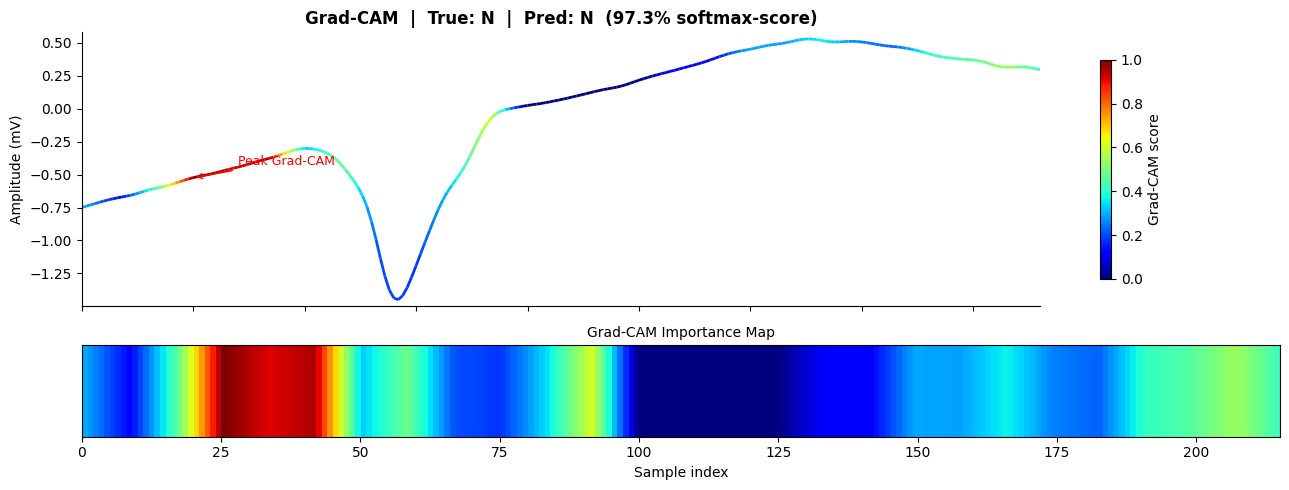

In [39]:
sample_idx   = 0
sample_sig   = X_test[sample_idx]
pred_probs_s = best_model.predict(sample_sig[np.newaxis], verbose=0)
pred_class   = int(np.argmax(pred_probs_s[0]))
true_class   = int(y_test[sample_idx])
conf         = pred_probs_s[0][pred_class]

heatmap = grad_cam_1d(
    best_model,
    sample_sig,
    class_index=pred_class,
    layer_name=None  # auto-select
)

plot_gradcam_ecg(
    sample_sig, heatmap,
    title=(
        f"Grad-CAM  |  "
        f"True: {encoder.classes_[true_class]}  |  "
        f"Pred: {encoder.classes_[pred_class]}  ({conf:.1%} softmax-score)"
    )
)

### 5.2 Grad-CAM Grid — One Correctly Classified Beat per Class

Compares which waveform regions the model attends to across arrhythmia types.

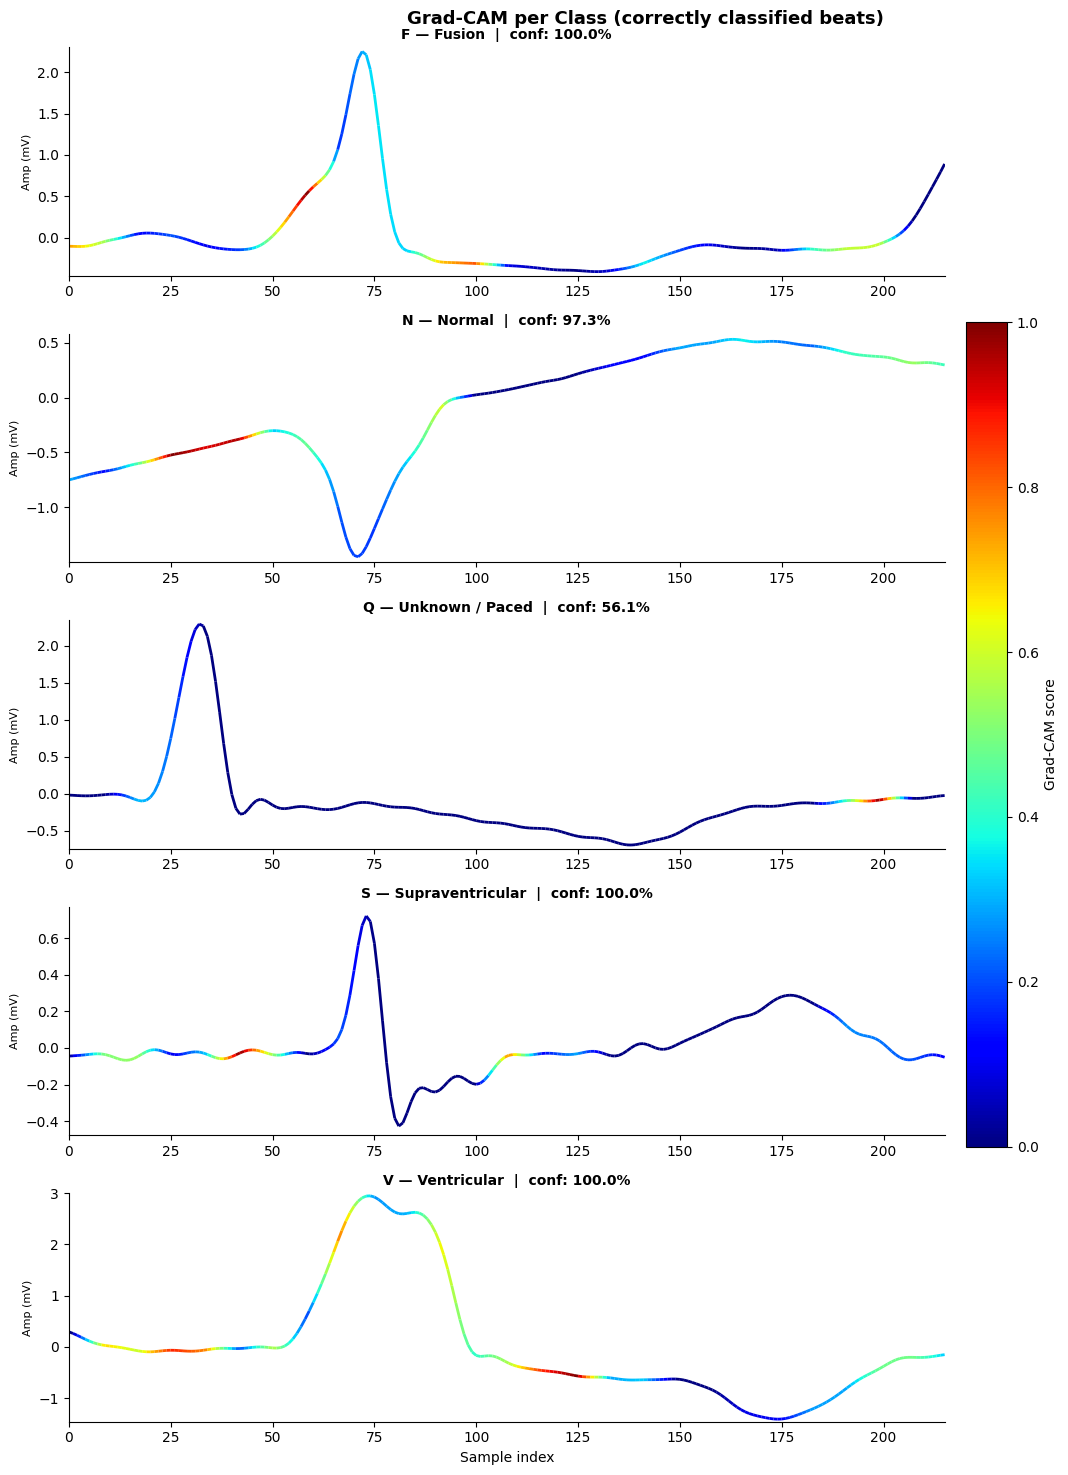

In [40]:
fig, axes = plt.subplots(
    len(labels_present), 1,
    figsize=(13, 3 * len(labels_present)),
    sharex=False,
)
if len(labels_present) == 1:
    axes = [axes]

norm = Normalize(vmin=0, vmax=1)

for ax, lbl in zip(axes, labels_present):
    candidates = np.where((y_true == lbl) & (y_pred == lbl))[0]
    if len(candidates) == 0:
        ax.set_visible(False)
        continue

    sig  = np.squeeze(X_test[candidates[0]])
    conf = y_pred_probs[candidates[0], lbl]
    hm   = grad_cam_1d(best_model, sig, class_index=int(lbl))
    t    = np.arange(len(sig))

    points   = np.array([t, sig]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="jet", norm=norm, linewidth=2)
    lc.set_array(hm[:-1])
    ax.add_collection(lc)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(sig.min() - 0.05, sig.max() + 0.05)

    cls_name = encoder.classes_[lbl]
    ax.set_title(
        f"{cls_name} — {LABEL_FULL.get(cls_name, '')}  |  conf: {conf:.1%}",
        fontsize=10, fontweight="bold"
    )
    ax.set_ylabel("Amp (mV)", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Sample index")
fig.suptitle(
    "Grad-CAM per Class (correctly classified beats)",
    fontsize=13, fontweight="bold"
)

# tight_layout BEFORE colorbar, with right margin reserved for it
fig.tight_layout(rect=[0, 0, 0.88, 1])

# Colorbar in the reserved margin
sm = plt.cm.ScalarMappable(cmap="jet", norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, label="Grad-CAM score", shrink=0.6, pad=0.02)

plt.show()

### SHAP ANALYSIS


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

# Load trained model
best_model = tf.keras.models.load_model(
    "models/cnn_ecg_tuned.keras"
)

# Select one ECG from test set
sample_idx = 0
x_explain = X_test[sample_idx:sample_idx+1]

# Prediction
prediction = best_model.predict(x_explain, verbose=0)
predicted_class = np.argmax(prediction[0])

print("ECG shape:", x_explain.shape)
print("Prediction probabilities:", prediction[0])
print("Predicted class:", predicted_class)

if 'y_test' in globals():
    print("True class:", y_test[sample_idx])

ECG shape: (1, 216, 1)
Prediction probabilities: [0.00420742 0.9730555  0.002213   0.00459192 0.0159323 ]
Predicted class: 1
True class: 1


In [42]:
# Background ECGs for SHAP
background = X_train[:50]

# Convert from (samples, 216, 1) → (samples, 216)
background_2d = background[:, :, 0]
x_explain_2d = x_explain[:, :, 0]

# Function SHAP will use
def model_predict(x):
    x = np.asarray(x)

    if x.ndim == 2:
        x = x[..., np.newaxis]

    return best_model.predict(x, verbose=0)

# Create SHAP explainer
explainer = shap.Explainer(
    model_predict,
    background_2d
)

# Calculate SHAP values
shap_result = explainer(x_explain_2d)

# SHAP values for the predicted class
shap_values = shap_result.values[0, :, predicted_class]

print("SHAP values shape:", shap_values.shape)
print("SHAP analysis completed.")

PermutationExplainer explainer: 2it [00:20, 20.03s/it]               

SHAP values shape: (216,)
SHAP analysis completed.


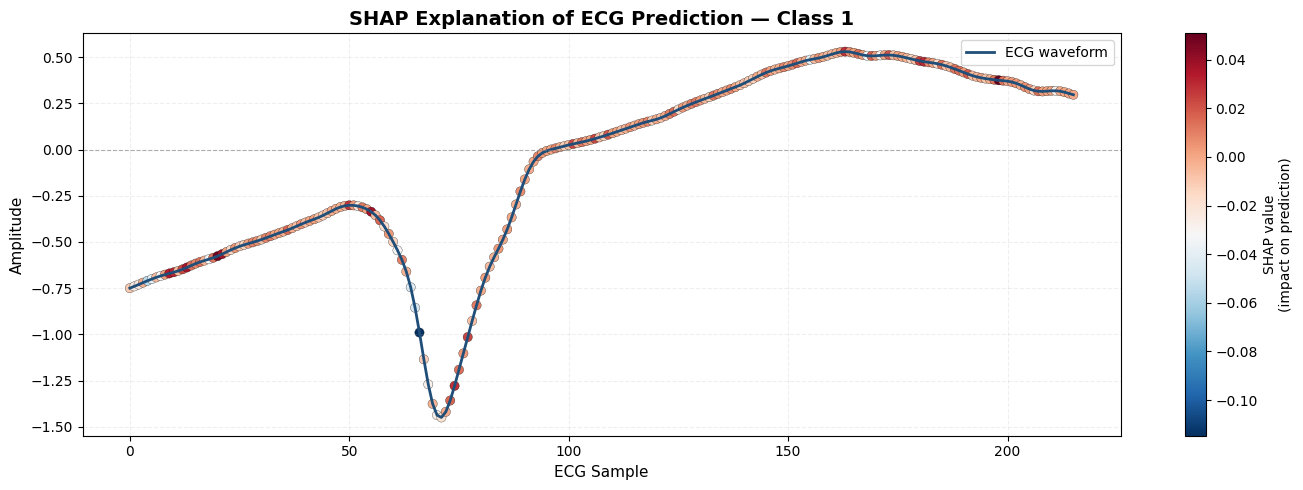

In [43]:
# ECG + SHAP visualization

ecg = x_explain[0, :, 0]

plt.figure(figsize=(14, 5))

# ECG waveform
plt.plot(
    ecg,
    color="#1f4e79",
    linewidth=2,
    label="ECG waveform"
)

# SHAP contribution
scatter = plt.scatter(
    np.arange(len(ecg)),
    ecg,
    c=shap_values,
    cmap="RdBu_r",
    s=45,
    edgecolors="black",
    linewidths=0.2
)

# Zero line for SHAP interpretation
plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=0.8,
    alpha=0.6
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(
    "SHAP value\n(impact on prediction)",
    fontsize=10
)

plt.xlabel("ECG Sample", fontsize=11)
plt.ylabel("Amplitude", fontsize=11)

plt.title(
    f"SHAP Explanation of ECG Prediction — Class {predicted_class}",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    alpha=0.2,
    linestyle="--"
)

plt.legend(
    loc="upper right",
    frameon=True
)

plt.tight_layout()
plt.show()